# Kiểm định giả thuyết: độ mở kinh tế, dự trữ ngoại hối và khả năng chống chịu của Việt Nam trong COVID

Notebook này kiểm định giả thuyết: dù Việt Nam có độ mở kinh tế cao, tăng trưởng GDP và lạm phát trong giai đoạn COVID vẫn tương đối ổn định nhờ dự trữ ngoại hối, cán cân thương mại và xuất nhập khẩu không đứt gãy mạnh.

Cách tiếp cận:
1. Chuẩn hóa dữ liệu macro Việt Nam và dữ liệu dự trữ ngoại hối.
2. Tạo các biến cơ chế: dự trữ/GDP, số tháng nhập khẩu được bảo đảm bởi dự trữ, cán cân thương mại/GDP, tăng trưởng xuất nhập khẩu.
3. So sánh trước COVID và trong COVID.
4. Chạy OLS cho Việt Nam để xem các biến cơ chế có liên hệ với GDP growth và lạm phát hay không.
5. So sánh Việt Nam với nhóm nước trong project bằng mô hình panel benchmark.

Lưu ý: dữ liệu là theo năm nên số quan sát nhỏ. Kết quả nên được xem là bằng chứng định lượng hỗ trợ/bác bỏ giả thuyết, không phải kết luận nhân quả tuyệt đối.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib
try:
    get_ipython
except NameError:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

DATA_DIR = Path('cleaned_data')
FIG_DIR = Path('fig')
FIG_DIR.mkdir(exist_ok=True)

## 1. Nạp và chuẩn hóa dữ liệu Việt Nam

In [2]:
macro = pd.read_csv(DATA_DIR / 'VNM_macro_cleaned.csv')
reserve = pd.read_csv(DATA_DIR / 'vietnam_forex_reserves.csv')

reserve = reserve.rename(columns={'year': 'Year', 'value_usd': 'Forex_Reserves_USD'})
df = macro.merge(reserve, on='Year', how='left').sort_values('Year').reset_index(drop=True)

df['Covid'] = df['Year'].between(2020, 2021).astype(int)
df['Covid_Extended'] = df['Year'].between(2020, 2022).astype(int)
df['Post_Covid'] = df['Year'].ge(2022).astype(int)

df['Reserve_to_GDP_Pct'] = df['Forex_Reserves_USD'] / df['GDP_Current_USD'] * 100
df['Reserve_Import_Months'] = df['Forex_Reserves_USD'] / (df['Imports_USD'] / 12)
df['Trade_Balance_to_GDP_Pct'] = df['Trade_Balance_USD'] / df['GDP_Current_USD'] * 100
df['Export_Growth_Pct'] = df['Exports_USD'].pct_change() * 100
df['Import_Growth_Pct'] = df['Imports_USD'].pct_change() * 100
df['Trade_Volume_Growth_Pct'] = (df['Exports_USD'] + df['Imports_USD']).pct_change() * 100
df['Export_Import_Ratio'] = df['Exports_USD'] / df['Imports_USD']

key_cols = [
    'Year', 'GDP_Growth_Pct', 'Inflation_CPI_Pct', 'Economic_Openness_Pct',
    'Forex_Reserves_USD', 'Reserve_to_GDP_Pct', 'Reserve_Import_Months',
    'Trade_Balance_to_GDP_Pct', 'Export_Growth_Pct', 'Import_Growth_Pct'
]
df[key_cols].tail(12)

,Year,GDP_Growth_Pct,Inflation_CPI_Pct,Economic_Openness_Pct,Forex_Reserves_USD,Reserve_to_GDP_Pct,Reserve_Import_Months,Trade_Balance_to_GDP_Pct,Export_Growth_Pct,Import_Growth_Pct
23,2013,5.554,6.593,130.846,"25,893,489,673.074",12.116,2.270,2.755,14.990,17.119
24,2014,6.422,4.085,135.411,"34,189,368,832.669",14.645,2.670,3.787,13.814,12.250
25,2015,6.987,0.631,144.914,"28,250,254,960.181",11.807,1.968,0.931,7.383,12.110
26,2016,6.690,2.668,145.410,"36,527,291,044.331",14.208,2.391,2.805,9.201,6.427
27,2017,6.940,3.520,160.980,"49,075,567,812.459",17.443,2.642,2.545,20.740,21.584
28,2018,7.465,3.540,164.664,"55,452,622,582.561",17.882,2.674,4.183,13.807,11.643
29,2019,7.359,2.796,164.704,"78,334,835,182.609",23.428,3.534,5.611,8.760,6.890
30,2020,2.865,3.221,163.246,"94,833,616,150.450",27.360,4.163,5.517,2.719,2.775
31,2021,2.554,1.835,186.676,"109,371,353,442.833",29.844,3.858,1.025,17.593,24.447
32,2022,8.538,3.157,183.154,"86,539,530,966.645",20.931,2.799,3.687,12.300,9.059


## 2. So sánh trước COVID và trong COVID

Nếu giả thuyết đúng, ta kỳ vọng giai đoạn 2020-2021 có: tăng trưởng GDP giảm nhưng vẫn dương, lạm phát không bùng nổ, dự trữ/GDP và số tháng nhập khẩu được bảo đảm bởi dự trữ ở mức tương đối cao, cán cân thương mại không suy sụp.

In [3]:
analysis_df = df[df['Year'].between(2010, 2024)].copy()

def period_label(year):
    if 2010 <= year <= 2019:
        return 'Pre-COVID 2010-2019'
    if 2020 <= year <= 2021:
        return 'COVID 2020-2021'
    if 2022 <= year <= 2024:
        return 'Post-COVID 2022-2024'
    return 'Other'

analysis_df['Period'] = analysis_df['Year'].map(period_label)

summary_vars = [
    'GDP_Growth_Pct', 'Inflation_CPI_Pct', 'Economic_Openness_Pct',
    'Reserve_to_GDP_Pct', 'Reserve_Import_Months', 'Trade_Balance_to_GDP_Pct',
    'Export_Growth_Pct', 'Import_Growth_Pct'
]

period_summary = (
    analysis_df.groupby('Period')[summary_vars]
    .agg(['mean', 'median', 'min', 'max'])
    .reindex(['Pre-COVID 2010-2019', 'COVID 2020-2021', 'Post-COVID 2022-2024'])
)
period_summary

GDP_Growth_Pct                    Inflation_CPI_Pct  \
                               mean median   min   max              mean   
Period                                                                     
Pre-COVID 2010-2019           6.576  6.557 5.505 7.465             6.081   
COVID 2020-2021               2.710  2.710 2.554 2.865             2.528   
Post-COVID 2022-2024          6.898  7.091 5.065 8.538             3.343   

                                         Economic_Openness_Pct          ...  \
                     median   min    max                  mean  median  ...   
Period                                                                  ...   
Pre-COVID 2010-2019   3.812 0.631 18.678               140.939 140.162  ...   
COVID 2020-2021       2.528 1.835  3.221               174.961 174.961  ...   
Post-COVID 2022-2024  3.253 3.157  3.621               173.945 173.862  ...   

                     Trade_Balance_to_GDP_Pct       Export_Growth_Pct         \
                                          min   max              mean median   
Period                                                                         
Pre-COVID 2010-2019                    -5.626 5.611            15.882 14.402   
COVID 2020-2021                         1.025 5.517            10.156 10.156   
Post-COVID 2022-2024                    3.687 8.117             7.971 12.300   

                                   Import_Growth_Pct                       
                        min    max              mean median    min    max  
Period                                                                     
Pre-COVID 2010-2019   7.383 32.410            13.450 12.180  5.666 25.640  
COVID 2020-2021       2.719 17.593            13.611 13.611  2.775 24.447  
Post-COVID 2022-2024 -2.873 14.485             5.998  9.059 -8.374 17.311  

[3 rows x 32 columns]

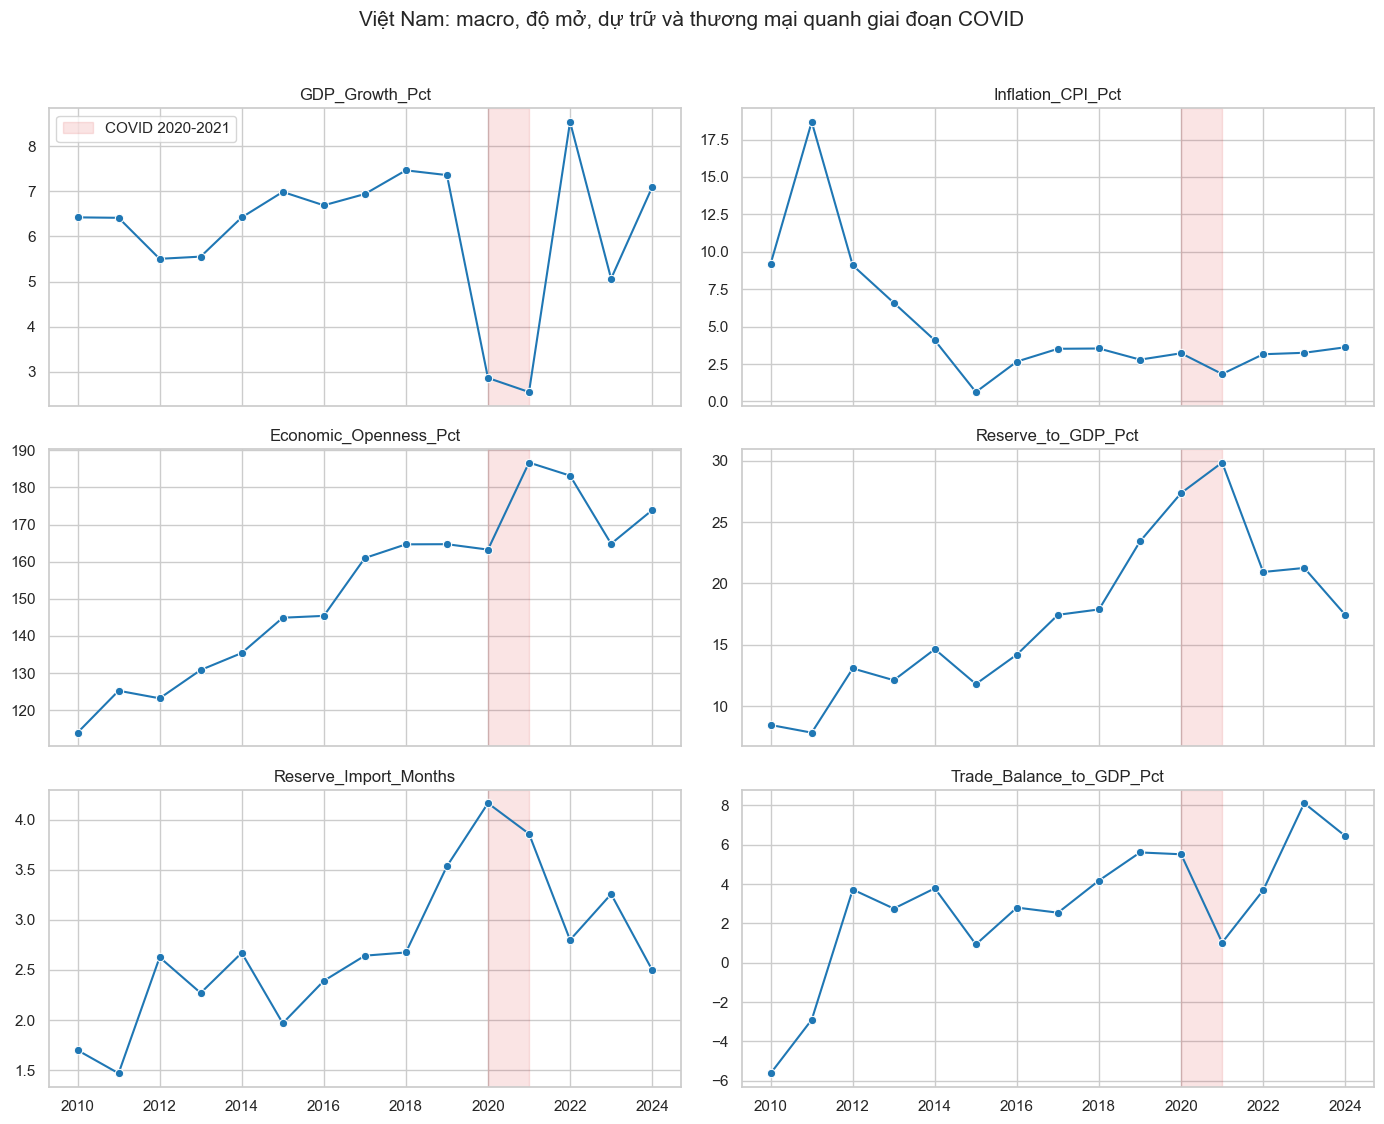

In [4]:
plot_cols = [
    'GDP_Growth_Pct', 'Inflation_CPI_Pct', 'Economic_Openness_Pct',
    'Reserve_to_GDP_Pct', 'Reserve_Import_Months', 'Trade_Balance_to_GDP_Pct'
]

fig, axes = plt.subplots(3, 2, figsize=(14, 11), sharex=True)
axes = axes.ravel()

for ax, col in zip(axes, plot_cols):
    sns.lineplot(data=analysis_df, x='Year', y=col, marker='o', ax=ax, color='#1f77b4')
    ax.axvspan(2020, 2021, color='#d62728', alpha=0.12, label='COVID 2020-2021')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('')

axes[0].legend(loc='best')
fig.suptitle('Việt Nam: macro, độ mở, dự trữ và thương mại quanh giai đoạn COVID', y=1.02, fontsize=15)
fig.tight_layout()
fig.savefig(FIG_DIR / 'kiem_dinh_covid_vn_timeseries.png', dpi=160, bbox_inches='tight')
plt.show()

## 3. Kiểm định trong nội bộ Việt Nam bằng OLS

Mô hình cơ bản:

`Y_t = Covid_t + Economic_Openness_t + Reserve_to_GDP_t + Reserve_Import_Months_t + Trade_Balance_to_GDP_t + Export_Growth_t + Import_Growth_t + trend + error_t`

Trong đó `Y_t` lần lượt là tăng trưởng GDP và lạm phát. Vì dữ liệu năm của Việt Nam ít quan sát, ta dùng robust standard errors HC3 và diễn giải chủ yếu theo dấu, độ lớn hệ số, R² và độ ổn định khi đổi đặc tả.

In [5]:
import statsmodels.formula.api as smf

model_df = df[df['Year'].between(1996, 2024)].copy()
model_df['Trend'] = model_df['Year'] - model_df['Year'].min()

controls = [
    'Covid', 'Economic_Openness_Pct', 'Reserve_to_GDP_Pct', 'Reserve_Import_Months',
    'Trade_Balance_to_GDP_Pct', 'Export_Growth_Pct', 'Import_Growth_Pct', 'Trend'
]

reg_df = model_df.dropna(subset=controls + ['GDP_Growth_Pct', 'Inflation_CPI_Pct']).copy()

formula_gdp = 'GDP_Growth_Pct ~ ' + ' + '.join(controls)
formula_inf = 'Inflation_CPI_Pct ~ ' + ' + '.join(controls)

gdp_model = smf.ols(formula_gdp, data=reg_df).fit(cov_type='HC3')
inf_model = smf.ols(formula_inf, data=reg_df).fit(cov_type='HC3')

def compact_results(model):
    return pd.DataFrame({
        'coef': model.params,
        'p_value': model.pvalues,
        'ci_low': model.conf_int()[0],
        'ci_high': model.conf_int()[1]
    }).round(4)

print('GDP growth model:')
display(compact_results(gdp_model))
print(f'R2={gdp_model.rsquared:.3f}, n={int(gdp_model.nobs)}')

print('\nInflation model:')
display(compact_results(inf_model))
print(f'R2={inf_model.rsquared:.3f}, n={int(inf_model.nobs)}')

GDP growth model:


,coef,p_value,ci_low,ci_high
Intercept,6.968,0.359,-7.918,21.855
Covid,-3.924,0.102,-8.632,0.783
Economic_Openness_Pct,0.024,0.619,-0.071,0.119
Reserve_to_GDP_Pct,0.257,0.641,-0.825,1.339
Reserve_Import_Months,-2.304,0.533,-9.546,4.939
Trade_Balance_to_GDP_Pct,0.089,0.375,-0.107,0.284
Export_Growth_Pct,0.021,0.531,-0.045,0.086
Import_Growth_Pct,0.019,0.603,-0.052,0.089
Trend,-0.140,0.168,-0.339,0.059


R2=0.709, n=29

Inflation model:


,coef,p_value,ci_low,ci_high
Intercept,13.714,0.647,-45.031,72.460
Covid,-3.830,0.378,-12.346,4.686
Economic_Openness_Pct,-0.236,0.286,-0.669,0.197
Reserve_to_GDP_Pct,0.611,0.739,-2.979,4.202
Reserve_Import_Months,-1.494,0.895,-23.711,20.723
Trade_Balance_to_GDP_Pct,-0.853,0.038,-1.658,-0.048
Export_Growth_Pct,0.438,0.030,0.042,0.834
Import_Growth_Pct,-0.291,0.108,-0.647,0.064
Trend,1.010,0.013,0.211,1.808


R2=0.613, n=29


## 4. Kiểm tra giả thuyết giảm sốc bằng residual

Ở bước này, ta ước lượng quan hệ trước COVID rồi dự báo cho 2020-2021. Nếu GDP thực tế cao hơn dự báo suy giảm hoặc lạm phát không vượt dự báo quá mạnh, đó là bằng chứng rằng Việt Nam chống chịu tốt hơn mức mô hình trước COVID dự đoán.

In [6]:
pre_df = model_df[model_df['Year'].between(1996, 2019)].dropna(subset=controls[1:] + ['GDP_Growth_Pct', 'Inflation_CPI_Pct']).copy()
covid_df = model_df[model_df['Year'].between(2020, 2021)].dropna(subset=controls[1:] + ['GDP_Growth_Pct', 'Inflation_CPI_Pct']).copy()

pre_controls = [c for c in controls if c != 'Covid']
pre_formula_gdp = 'GDP_Growth_Pct ~ ' + ' + '.join(pre_controls)
pre_formula_inf = 'Inflation_CPI_Pct ~ ' + ' + '.join(pre_controls)

pre_gdp_model = smf.ols(pre_formula_gdp, data=pre_df).fit(cov_type='HC3')
pre_inf_model = smf.ols(pre_formula_inf, data=pre_df).fit(cov_type='HC3')

shock = covid_df[['Year', 'GDP_Growth_Pct', 'Inflation_CPI_Pct']].copy()
shock['GDP_Pred_PreCovid_Model'] = pre_gdp_model.predict(covid_df)
shock['Inflation_Pred_PreCovid_Model'] = pre_inf_model.predict(covid_df)
shock['GDP_Residual'] = shock['GDP_Growth_Pct'] - shock['GDP_Pred_PreCovid_Model']
shock['Inflation_Residual'] = shock['Inflation_CPI_Pct'] - shock['Inflation_Pred_PreCovid_Model']
shock

,Year,GDP_Growth_Pct,Inflation_CPI_Pct,GDP_Pred_PreCovid_Model,Inflation_Pred_PreCovid_Model,GDP_Residual,Inflation_Residual
30,2020,2.865,3.221,5.592,6.075,-2.727,-2.854
31,2021,2.554,1.835,8.099,9.808,-5.545,-7.974


## 5. Benchmark panel: Việt Nam so với các nước khác trong project

Dữ liệu dự trữ ngoại hối hiện chỉ có riêng Việt Nam, nên phần panel không kiểm định trực tiếp cơ chế dự trữ. Phần này trả lời câu hỏi phụ: trong cùng giai đoạn COVID, Việt Nam có kết quả GDP/lạm phát khác biệt so với các nước còn lại sau khi kiểm soát độ mở, cán cân thương mại, FDI/GDP và xu hướng thời gian hay không.

In [7]:
panel_frames = []
for path in DATA_DIR.glob('*_macro_cleaned.csv'):
    country = path.stem.replace('_macro_cleaned', '')
    tmp = pd.read_csv(path)
    tmp['Country'] = country
    panel_frames.append(tmp)

panel = pd.concat(panel_frames, ignore_index=True)
panel['Covid'] = panel['Year'].between(2020, 2021).astype(int)
panel['Is_VNM'] = (panel['Country'] == 'VNM').astype(int)
panel['Trend'] = panel['Year'] - panel['Year'].min()
panel['Trade_Balance_to_GDP_Pct'] = panel['Trade_Balance_USD'] / panel['GDP_Current_USD'] * 100
panel['Trade_Volume_USD'] = panel['Exports_USD'] + panel['Imports_USD']
panel['Trade_Volume_Growth_Pct'] = panel.groupby('Country')['Trade_Volume_USD'].pct_change() * 100

panel = panel[panel['Year'].between(1996, 2024)].copy()

panel_controls = [
    'Covid', 'Is_VNM', 'Covid:Is_VNM', 'Economic_Openness_Pct',
    'Trade_Balance_to_GDP_Pct', 'FDI_to_GDP_Pct', 'Trade_Volume_Growth_Pct', 'Trend'
]
panel_reg = panel.dropna(subset=['GDP_Growth_Pct', 'Inflation_CPI_Pct'] + [c for c in panel_controls if ':' not in c]).copy()

panel_formula_gdp = 'GDP_Growth_Pct ~ Covid * Is_VNM + Economic_Openness_Pct + Trade_Balance_to_GDP_Pct + FDI_to_GDP_Pct + Trade_Volume_Growth_Pct + Trend + C(Country)'
panel_formula_inf = 'Inflation_CPI_Pct ~ Covid * Is_VNM + Economic_Openness_Pct + Trade_Balance_to_GDP_Pct + FDI_to_GDP_Pct + Trade_Volume_Growth_Pct + Trend + C(Country)'

panel_gdp_model = smf.ols(panel_formula_gdp, data=panel_reg).fit(cov_type='cluster', cov_kwds={'groups': panel_reg['Country']})
panel_inf_model = smf.ols(panel_formula_inf, data=panel_reg).fit(cov_type='cluster', cov_kwds={'groups': panel_reg['Country']})

display(compact_results(panel_gdp_model).loc[['Covid', 'Is_VNM', 'Covid:Is_VNM']])
print(f'Panel GDP model: R2={panel_gdp_model.rsquared:.3f}, n={int(panel_gdp_model.nobs)}')

display(compact_results(panel_inf_model).loc[['Covid', 'Is_VNM', 'Covid:Is_VNM']])
print(f'Panel inflation model: R2={panel_inf_model.rsquared:.3f}, n={int(panel_inf_model.nobs)}')

,coef,p_value,ci_low,ci_high
Covid,-2.571,0.006,-4.393,-0.750
Is_VNM,1.259,0.011,0.295,2.224
Covid:Is_VNM,-0.870,0.472,-3.238,1.498


Panel GDP model: R2=0.598, n=493


,coef,p_value,ci_low,ci_high
Covid,-0.359,0.348,-1.110,0.392
Is_VNM,-2.155,0.152,-5.105,0.795
Covid:Is_VNM,-3.272,0.002,-5.302,-1.242


Panel inflation model: R2=0.328, n=493


## 6. Diễn giải nhanh kết quả

Sau khi chạy notebook, hãy đọc kết quả theo logic sau:

- Nếu `Reserve_to_GDP_Pct` hoặc `Reserve_Import_Months` có hệ số dương trong mô hình GDP growth, hoặc âm/không đáng kể trong mô hình lạm phát, kết quả ủng hộ giả thuyết dự trữ giúp ổn định kinh tế.
- Nếu `Trade_Balance_to_GDP_Pct`, `Export_Growth_Pct`, `Import_Growth_Pct` có quan hệ tích cực với GDP growth và không làm lạm phát tăng mạnh, kết quả ủng hộ kênh thương mại ổn định.
- Nếu `Covid:Is_VNM` trong panel GDP là dương, Việt Nam chống chịu GDP tốt hơn nhóm benchmark trong COVID. Nếu `Covid:Is_VNM` trong panel lạm phát là âm hoặc không đáng kể, Việt Nam không chịu áp lực lạm phát bất thường so với nhóm benchmark.
- Nếu các hệ số không có ý nghĩa thống kê, không nên kết luận giả thuyết sai ngay; với dữ liệu năm, số quan sát COVID chỉ có 2 năm nên power thống kê thấp. Khi đó nên dùng kết quả mô tả và residual như bằng chứng bổ trợ.

In [8]:
evidence = {
    'GDP_growth_COVID_mean': analysis_df.loc[analysis_df['Covid'].eq(1), 'GDP_Growth_Pct'].mean(),
    'Inflation_COVID_mean': analysis_df.loc[analysis_df['Covid'].eq(1), 'Inflation_CPI_Pct'].mean(),
    'Reserve_to_GDP_COVID_mean': analysis_df.loc[analysis_df['Covid'].eq(1), 'Reserve_to_GDP_Pct'].mean(),
    'Reserve_import_months_COVID_mean': analysis_df.loc[analysis_df['Covid'].eq(1), 'Reserve_Import_Months'].mean(),
    'Trade_balance_to_GDP_COVID_mean': analysis_df.loc[analysis_df['Covid'].eq(1), 'Trade_Balance_to_GDP_Pct'].mean(),
    'Panel_GDP_Covid_Is_VNM_coef': panel_gdp_model.params.get('Covid:Is_VNM', np.nan),
    'Panel_GDP_Covid_Is_VNM_p_value': panel_gdp_model.pvalues.get('Covid:Is_VNM', np.nan),
    'Panel_Inflation_Covid_Is_VNM_coef': panel_inf_model.params.get('Covid:Is_VNM', np.nan),
    'Panel_Inflation_Covid_Is_VNM_p_value': panel_inf_model.pvalues.get('Covid:Is_VNM', np.nan),
}

pd.Series(evidence).to_frame('value').round(4)

,value
GDP_growth_COVID_mean,2.710
Inflation_COVID_mean,2.528
Reserve_to_GDP_COVID_mean,28.602
Reserve_import_months_COVID_mean,4.011
Trade_balance_to_GDP_COVID_mean,3.271
Panel_GDP_Covid_Is_VNM_coef,-0.870
Panel_GDP_Covid_Is_VNM_p_value,0.472
Panel_Inflation_Covid_Is_VNM_coef,-3.272
Panel_Inflation_Covid_Is_VNM_p_value,0.002
